# Exotic single-image stress tests

This notebook takes the same compact format as the headline-result notebook, but replaces the cached vortex-disc fixture with three deliberately harder synthetic 3D objects reconstructed from a single phase image.

The objects are chosen to stress different failure modes of single-image 3D inversion:

1. A helical vortex stack with depth-dependent in-plane rotation
2. An annular meron-like ring with oscillatory out-of-plane content
3. A wall-vortex hybrid that mixes a domain wall and a localized vortex

All runs use the same hard zero-start and the same physics-backed inversion path that worked in the previous notebook.

In [2]:

# Imports and helpers
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1'

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import optax

import numpy as np
import matplotlib.pyplot as plt
import unxt as u
import neuralmag as nm  # type: ignore[import-not-found]

from libertem_holo.base.mbir import add_units_to_inputs, invert_magnetization, lcurve_sweep_vmap, NeuralMagCritic, reconstruct_2d, support_center_yx
from libertem_holo.base.mbir.forward import forward_phase_from_density_and_magnetization
from libertem_holo.base.mbir.inversion.solver import project_unit_norm
from libertem_holo.base.mbir.synthetic import soft_disc_support, vortex_magnetization, domain_wall_magnetization

SIZE = 24
PIXEL_SIZE = u.Quantity(5.0, 'nm')
MAX_ITER = 500
LEARNING_RATE = 1e-3
MULTIVIEW_ANGLES_DEG = (-25.0, 0.0, 25.0)
MULTIVIEW_MAX_ITER = 160
MULTIVIEW_LEARNING_RATE = 1.0
MULTIVIEW_OPTIMIZER = 'lbfgs'
MULTIVIEW_LBFGS_MEMORY_SIZE = 10
COPLANAR_TILT_ANGLES_DEG = (15.0, 25.0, 35.0, 45.0, 55.0, 65.0, 75.0, 85.0)
# lambda_phys=1e-8 provides light exchange+demag regularisation.
# Previously all runs produced NaN loss because jnp.linalg.norm's VJP
# evaluates m/‖m‖ at zero-norm voxels (g·0/0=NaN even when g=0).
# That bug has been fixed in project_unit_norm (sqrt(∑m²+ε²)), so
# physics-backed runs now converge normally.
LAMBDA_PHYS = 1e-8

def normalize_field(m, rho, eps=1e-6):
    norms = np.linalg.norm(m, axis=-1, keepdims=True)
    safe_norms = np.where(norms > eps, norms, 1.0)
    unit = m / safe_norms
    fallback = np.zeros_like(unit)
    fallback[..., 0] = 1.0
    unit = np.where(norms > eps, unit, fallback)
    return np.where(rho[..., None] > 0.05, unit, 0.0).astype(np.float32)

def projected_from_volume(rho_zyx, m_zyxc):
    return np.sum(np.asarray(rho_zyx)[..., None] * np.asarray(m_zyxc), axis=0)[..., :2]

def phase_rms(pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    return float(np.sqrt(np.mean((pred - true) ** 2)))

def projected_rel_err(pred, true, mask=None, eps=1e-12):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    if mask is not None:
        pred = pred * mask[..., None]
        true = true * mask[..., None]
    return float(np.linalg.norm((pred - true).ravel()) / max(np.linalg.norm(true.ravel()), eps))

def make_neuralmag_backend(rho, pixel_size_nm):
    mesh = nm.Mesh(rho.shape, (pixel_size_nm * 1e-9,) * 3)
    state = nm.State(mesh)
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.asarray(rho, dtype=np.float32)))
    state.material.Ms = nm.CellFunction(state).fill(8e5)
    state.material.A = nm.CellFunction(state).fill(1.3e-11)
    state.m = nm.VectorCellFunction(state, tensor=state.tensor(np.zeros(rho.shape + (3,), dtype=np.float32)))
    nm.ExchangeField().register(state, 'exchange')
    nm.DemagField(p=1).register(state, 'demag')
    return NeuralMagCritic.from_state(state, terms=('exchange', 'demag'))

def extrude_projected_init(rho, projected_m):
    init = np.zeros(rho.shape + (3,), dtype=np.float32)
    init[..., 0] = projected_m[None, ..., 0]
    init[..., 1] = projected_m[None, ..., 1]
    return normalize_field(init, rho)

def make_y_rotation_coords(shape, angle_deg, dtype=jnp.float32):
    nz, ny, nx = shape
    cz = jnp.asarray((nz - 1) / 2.0, dtype=dtype)
    cy = jnp.asarray((ny - 1) / 2.0, dtype=dtype)
    cx = jnp.asarray((nx - 1) / 2.0, dtype=dtype)
    zz, yy, xx = jnp.meshgrid(
        jnp.arange(nz, dtype=dtype),
        jnp.arange(ny, dtype=dtype),
        jnp.arange(nx, dtype=dtype),
        indexing='ij',
    )
    zc = zz - cz
    yc = yy - cy
    xc = xx - cx
    theta = jnp.asarray(np.deg2rad(angle_deg), dtype=dtype)
    z_in = jnp.sin(theta) * xc + jnp.cos(theta) * zc + cz
    x_in = jnp.cos(theta) * xc - jnp.sin(theta) * zc + cx
    y_in = yc + cy
    return jnp.stack([z_in, y_in, x_in], axis=0)

def rotate_scalar_y_jax(values, coords):
    return jax.scipy.ndimage.map_coordinates(
        jnp.asarray(values), coords, order=1, mode='constant', cval=0.0,
    )

def rotate_vector_y_jax(magnetization, coords, angle_deg, rho_rot, projection_threshold=0.0):
    mx = rotate_scalar_y_jax(magnetization[..., 0], coords)
    my = rotate_scalar_y_jax(magnetization[..., 1], coords)
    mz = rotate_scalar_y_jax(magnetization[..., 2], coords)
    theta = jnp.asarray(np.deg2rad(angle_deg), dtype=mx.dtype)
    rotated = jnp.stack([
        jnp.cos(theta) * mx + jnp.sin(theta) * mz,
        my,
        -jnp.sin(theta) * mx + jnp.cos(theta) * mz,
    ], axis=-1)
    return project_unit_norm(rotated, rho_rot, threshold=projection_threshold)

def initial_m_from_init(rho, init):
    shape = tuple(rho.shape) + (3,)
    if isinstance(init, str):
        if init == 'zero':
            return jnp.zeros(shape, dtype=rho.dtype)
        if init == 'uniform_x':
            return jnp.broadcast_to(jnp.asarray([1.0, 0.0, 0.0], dtype=rho.dtype), shape)
        raise ValueError(f'Unknown init strategy {init!r}.')
    init_arr = jnp.asarray(init, dtype=rho.dtype)
    if init_arr.shape != shape:
        raise ValueError(f'Custom init must have shape {shape}, got {init_arr.shape}.')
    return init_arr

def synthesize_tilted_views(rho_true, m_true, angles_deg=MULTIVIEW_ANGLES_DEG, projection_threshold=0.0):
    rho_arr = jnp.asarray(rho_true, dtype=jnp.float32)
    m_arr = jnp.asarray(m_true, dtype=jnp.float32)
    views = {}
    for angle in angles_deg:
        coords = make_y_rotation_coords(rho_arr.shape, angle, dtype=rho_arr.dtype)
        rho_view = rotate_scalar_y_jax(rho_arr, coords)
        m_view = rotate_vector_y_jax(m_arr, coords, angle, rho_view, projection_threshold=projection_threshold)
        phi_view = forward_phase_from_density_and_magnetization(
            rho=rho_view, magnetization_3d=m_view, pixel_size=PIXEL_SIZE, axis='z',
        )
        views[angle] = {
            'rho': np.asarray(rho_view, dtype=np.float32),
            'm_true': np.asarray(m_view, dtype=np.float32),
            'phi_true': np.asarray(phi_view, dtype=np.float32),
        }
    return views

def invert_magnetization_multiview(
    phi_views, rho, backend, *, pixel_size, angles_deg=MULTIVIEW_ANGLES_DEG, lambda_phys=0.0,
    max_iter=MULTIVIEW_MAX_ITER, lr=MULTIVIEW_LEARNING_RATE, init='zero', projection_threshold=0.0,
    optimizer=MULTIVIEW_OPTIMIZER, lbfgs_memory_size=MULTIVIEW_LBFGS_MEMORY_SIZE,
    ):
    rho_arr = jnp.asarray(rho, dtype=jnp.float32)
    pixel_size_q = pixel_size if isinstance(pixel_size, u.Quantity) else u.Quantity(float(pixel_size), 'nm')
    phi_targets = tuple(jnp.asarray(phi_views[angle], dtype=jnp.float32) for angle in angles_deg)
    coords_by_angle = tuple(make_y_rotation_coords(rho_arr.shape, angle, dtype=rho_arr.dtype) for angle in angles_deg)
    rho_by_angle = tuple(rotate_scalar_y_jax(rho_arr, coords) for coords in coords_by_angle)
    m0 = project_unit_norm(initial_m_from_init(rho_arr, init), rho_arr, threshold=projection_threshold)
    use_physics = float(lambda_phys) != 0.0
    optimizer_name = optimizer.lower()

    def loss_components(m_current):
        m_projected = project_unit_norm(m_current, rho_arr, threshold=projection_threshold)
        phi_preds = []
        data_loss = jnp.asarray(0.0, dtype=rho_arr.dtype)
        for angle, phi_target, coords, rho_view in zip(angles_deg, phi_targets, coords_by_angle, rho_by_angle):
            m_view = rotate_vector_y_jax(
                m_projected, coords, angle, rho_view, projection_threshold=projection_threshold,
            )
            phi_pred = forward_phase_from_density_and_magnetization(
                rho=rho_view, magnetization_3d=m_view, pixel_size=pixel_size_q, axis='z',
            )
            phi_preds.append(phi_pred)
            data_loss = data_loss + 0.5 * jnp.mean((phi_pred - phi_target) ** 2)
        data_loss = data_loss / len(angles_deg)
        if use_physics:
            field = backend.prepare(rho_arr, m_projected)
            energy_terms = backend.energies(field)
            if energy_terms:
                physics_loss = jnp.sum(jnp.stack(tuple(energy_terms.values())))
            else:
                physics_loss = jnp.asarray(0.0, dtype=data_loss.dtype)
        else:
            physics_loss = jnp.asarray(0.0, dtype=data_loss.dtype)
        total_loss = data_loss + lambda_phys * physics_loss
        return total_loss, (m_projected, jnp.stack(phi_preds, axis=0))

    loss_and_grad = jax.value_and_grad(loss_components, has_aux=True)

    def scalar_loss(m_current):
        loss_value, _aux = loss_components(m_current)
        return loss_value

    if optimizer_name == 'lbfgs':
        opt = optax.lbfgs(learning_rate=lr, memory_size=lbfgs_memory_size)

        @jax.jit
        def step(m_current, opt_state_current):
            (loss_value, (m_projected, phi_preds)), grads = loss_and_grad(m_current)
            updates, next_opt_state = opt.update(
                grads,
                opt_state_current,
                m_current,
                value=loss_value,
                grad=grads,
                value_fn=scalar_loss,
            )
            next_m = optax.apply_updates(m_current, updates)
            next_m = project_unit_norm(next_m, rho_arr, threshold=projection_threshold)
            return next_m, next_opt_state, loss_value, m_projected, phi_preds
    else:
        opt = optax.adam(lr)

        @jax.jit
        def step(m_current, opt_state_current):
            (loss_value, (m_projected, phi_preds)), grads = loss_and_grad(m_current)
            updates, next_opt_state = opt.update(grads, opt_state_current, m_current)
            next_m = optax.apply_updates(m_current, updates)
            next_m = project_unit_norm(next_m, rho_arr, threshold=projection_threshold)
            return next_m, next_opt_state, loss_value, m_projected, phi_preds

    opt_state = opt.init(m0)
    loss_history = []
    m_current = m0
    phi_preds = None
    best_m = m0
    best_loss = np.inf
    for _ in range(max_iter):
        m_current, opt_state, loss_value, m_projected, phi_preds = step(m_current, opt_state)
        loss_scalar = float(loss_value)
        loss_history.append(loss_scalar)
        if np.isfinite(loss_scalar) and loss_scalar < best_loss:
            best_loss = loss_scalar
            best_m = m_projected

    _loss_final, (best_m, phi_preds_final) = loss_components(best_m)
    return {
        'm_recon': np.asarray(best_m, dtype=np.float32),
        'phi_pred_views': np.asarray(phi_preds_final, dtype=np.float32),
        'loss_history': np.asarray(loss_history, dtype=np.float32),
        'optimizer': optimizer_name,
    }

def show_every_fourth_slices(case_name, rho_true, m_true, m_recon):
    slice_indices = list(range(0, m_true.shape[0], 4))
    components = [(0, 'Mx'), (1, 'My'), (2, 'Mz')]
    fig, axes = plt.subplots(len(slice_indices), 6, figsize=(13, 2.0 * len(slice_indices)), squeeze=False)
    last_im = None
    for row_idx, z_idx in enumerate(slice_indices):
        support = rho_true[z_idx] > 0.25
        for comp_offset, (comp_idx, comp_name) in enumerate(components):
            ax_t = axes[row_idx, comp_offset]
            ax_r = axes[row_idx, comp_offset + 3]
            ax_t.imshow(m_true[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
            last_im = ax_r.imshow(m_recon[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
            ax_t.contour(support, levels=[0.5], colors='k', linewidths=0.4)
            ax_r.contour(support, levels=[0.5], colors='k', linewidths=0.4)
            if row_idx == 0:
                ax_t.set_title(f'Truth {comp_name}', fontsize=9)
                ax_r.set_title(f'Recon {comp_name}', fontsize=9)
            ax_t.set_ylabel(f'z={z_idx}', fontsize=8)
            ax_t.set_xticks([])
            ax_t.set_yticks([])
            ax_r.set_xticks([])
            ax_r.set_yticks([])

    plt.suptitle(f'{case_name}: every 4th z-slice', y=1.0)
    plt.tight_layout()
    plt.show()


/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.9.1 is installed, but it is not compatible with the installed jaxlib version 0.9.0, so it will not be used.
  warnings.warn(
2026-04-21 11:08:24 NeuralMag:INFO [NeuralMag] Version 0.9.4


In [2]:
# Build three exotic 3D objects and their single-image phase measurements
z_idx, y_idx, x_idx = np.indices((SIZE, SIZE, SIZE), dtype=np.float32)
cy = cx = (SIZE - 1) / 2.0
angle_yx = np.arctan2(y_idx - cy, x_idx - cx)

cases = {}

rho_helical = np.asarray(soft_disc_support((SIZE, SIZE, SIZE), radius=0.28 * SIZE, edge_width=1.1), dtype=np.float32)
base_vortex = np.asarray(vortex_magnetization((SIZE, SIZE, SIZE), support_zyx=jnp.asarray(rho_helical), core_radius=2.0), dtype=np.float32)
angles_z = np.linspace(0.0, 1.25 * np.pi, SIZE, dtype=np.float32)[:, None, None]
mx_helix = np.cos(angles_z) * base_vortex[..., 0] - np.sin(angles_z) * base_vortex[..., 1]
my_helix = np.sin(angles_z) * base_vortex[..., 0] + np.cos(angles_z) * base_vortex[..., 1]
mz_helix = 0.55 * base_vortex[..., 2] + 0.35 * np.sin(angles_z)
m_helical = normalize_field(np.stack([mx_helix, my_helix, mz_helix], axis=-1), rho_helical)
phi_helical = np.asarray(forward_phase_from_density_and_magnetization(rho=rho_helical, magnetization_3d=m_helical, pixel_size=PIXEL_SIZE, axis='z'), dtype=np.float32)
cases['helical_vortex'] = {'title': 'Helical vortex stack', 'rho_true': rho_helical, 'm_true': m_helical, 'phi_true': phi_helical}

outer_ring = np.asarray(soft_disc_support((SIZE, SIZE, SIZE), radius=0.34 * SIZE, edge_width=1.0), dtype=np.float32)
inner_ring = np.asarray(soft_disc_support((SIZE, SIZE, SIZE), radius=0.16 * SIZE, edge_width=1.0), dtype=np.float32)
rho_annulus = np.clip(outer_ring - inner_ring, 0.0, 1.0).astype(np.float32)
m_annulus = np.zeros(rho_annulus.shape + (3,), dtype=np.float32)
m_annulus[..., 0] = -np.sin(angle_yx)
m_annulus[..., 1] = np.cos(angle_yx)
m_annulus[..., 2] = 0.55 * np.sin(2.0 * np.pi * z_idx / max(SIZE - 1, 1))
m_annulus = normalize_field(m_annulus, rho_annulus)
phi_annulus = np.asarray(forward_phase_from_density_and_magnetization(rho=rho_annulus, magnetization_3d=m_annulus, pixel_size=PIXEL_SIZE, axis='z'), dtype=np.float32)
cases['annular_meron'] = {'title': 'Annular meron-like ring', 'rho_true': rho_annulus, 'm_true': m_annulus, 'phi_true': phi_annulus}

rho_hybrid = np.asarray(soft_disc_support((SIZE, SIZE, SIZE), radius=0.30 * SIZE, edge_width=1.1), dtype=np.float32)
wall_field = np.asarray(domain_wall_magnetization((SIZE, SIZE, SIZE), support_zyx=jnp.asarray(rho_hybrid), wall_width=2.5), dtype=np.float32)
vortex_field = np.asarray(vortex_magnetization((SIZE, SIZE, SIZE), support_zyx=jnp.asarray(rho_hybrid), core_radius=2.4, chirality=-1.0), dtype=np.float32)
hybrid_weight = np.exp(-((z_idx - 0.35 * SIZE) / (0.18 * SIZE)) ** 2)[..., None]
m_hybrid = normalize_field(0.65 * wall_field + 0.90 * hybrid_weight * vortex_field, rho_hybrid)
phi_hybrid = np.asarray(forward_phase_from_density_and_magnetization(rho=rho_hybrid, magnetization_3d=m_hybrid, pixel_size=PIXEL_SIZE, axis='z'), dtype=np.float32)
cases['wall_vortex_hybrid'] = {'title': 'Wall-vortex hybrid', 'rho_true': rho_hybrid, 'm_true': m_hybrid, 'phi_true': phi_hybrid}

for case_name, case in cases.items():
    print(case_name, case['rho_true'].shape, case['m_true'].shape, case['phi_true'].shape, support_center_yx(case['rho_true'], threshold=0.25))

W0420 22:43:10.094375  779412 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning


helical_vortex (24, 24, 24) (24, 24, 24, 3) (24, 24) (12, 12)
annular_meron (24, 24, 24) (24, 24, 24, 3) (24, 24) (12, 12)
wall_vortex_hybrid (24, 24, 24) (24, 24, 24, 3) (24, 24) (12, 12)


In [3]:
# RUN: reconstruct each object from its single phase image using the same hard zero-start
stress_results = {}
summary_rows = []

for case_name, case in cases.items():
    rho_true = case['rho_true']
    m_true = case['m_true']
    phi_true = case['phi_true']
    backend = make_neuralmag_backend(rho_true, float(PIXEL_SIZE.value))
    result = invert_magnetization(
        phi_true,
        rho_true,
        backend,
        pixel_size=PIXEL_SIZE,
        lambda_phys=LAMBDA_PHYS,
        max_iter=MAX_ITER,
        lr=LEARNING_RATE,
        init='zero',
        axis='z',
        projection_threshold=0.0,
    )
    m_recon = np.asarray(result.m_recon)
    phi_pred = np.asarray(result.phi_pred)
    proj_true = projected_from_volume(rho_true, m_true)
    proj_recon = projected_from_volume(rho_true, m_recon)
    support_2d = (np.max(rho_true, axis=0) > 0.25).astype(np.float32)
    stress_results[case_name] = {
        'title': case['title'],
        'rho_true': rho_true,
        'm_true': m_true,
        'phi_true': phi_true,
        'm_recon': m_recon,
        'phi_pred': phi_pred,
        'proj_true': proj_true,
        'proj_recon': proj_recon,
        'loss_history': np.asarray(result.loss_history),
    }
    summary_rows.append({
        'case': case_name,
        'title': case['title'],
        'phase_rms': phase_rms(phi_pred, phi_true),
        'projected_rel_err': projected_rel_err(proj_recon, proj_true, support_2d),
        'loss_final': float(np.asarray(result.loss_history)[-1]),
    })

art_dir = os.path.join(os.path.dirname(os.getcwd()), 'artifacts')
os.makedirs(art_dir, exist_ok=True)
artifact_path = os.path.join(art_dir, 'exotic_single_image_stress_tests.npz')
np.savez_compressed(artifact_path, summary_rows=np.asarray(summary_rows, dtype=object), stress_results=np.asarray(stress_results, dtype=object))
print('Stress-test artifact saved to', artifact_path)

2026-04-20 22:43:16 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 22:43:16 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-20 22:43:16 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 22:43:16 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-20 22:43:16 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 22:43:16 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-20 22:43:16 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-20 22:43:16 NeuralMag:INFO [DemagField]: Set up demag tensor
W0420 22:43:23.557477  779407 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning
W0420 22:43:23.567255  779408 autotuner.cc:583] No reference output found even though buffer ch

Stress-test artifact saved to /Users/landers/LiberTEM-holo/notebooks/MBIR/artifacts/exotic_single_image_stress_tests.npz


Case                      phase_rms   proj_rel_err   loss_final
----------------------------------------------------------------
helical_vortex             0.631659       1.980282     0.200608
annular_meron              1.058235       0.896422     0.561808
wall_vortex_hybrid         0.759081       1.315522     0.289681


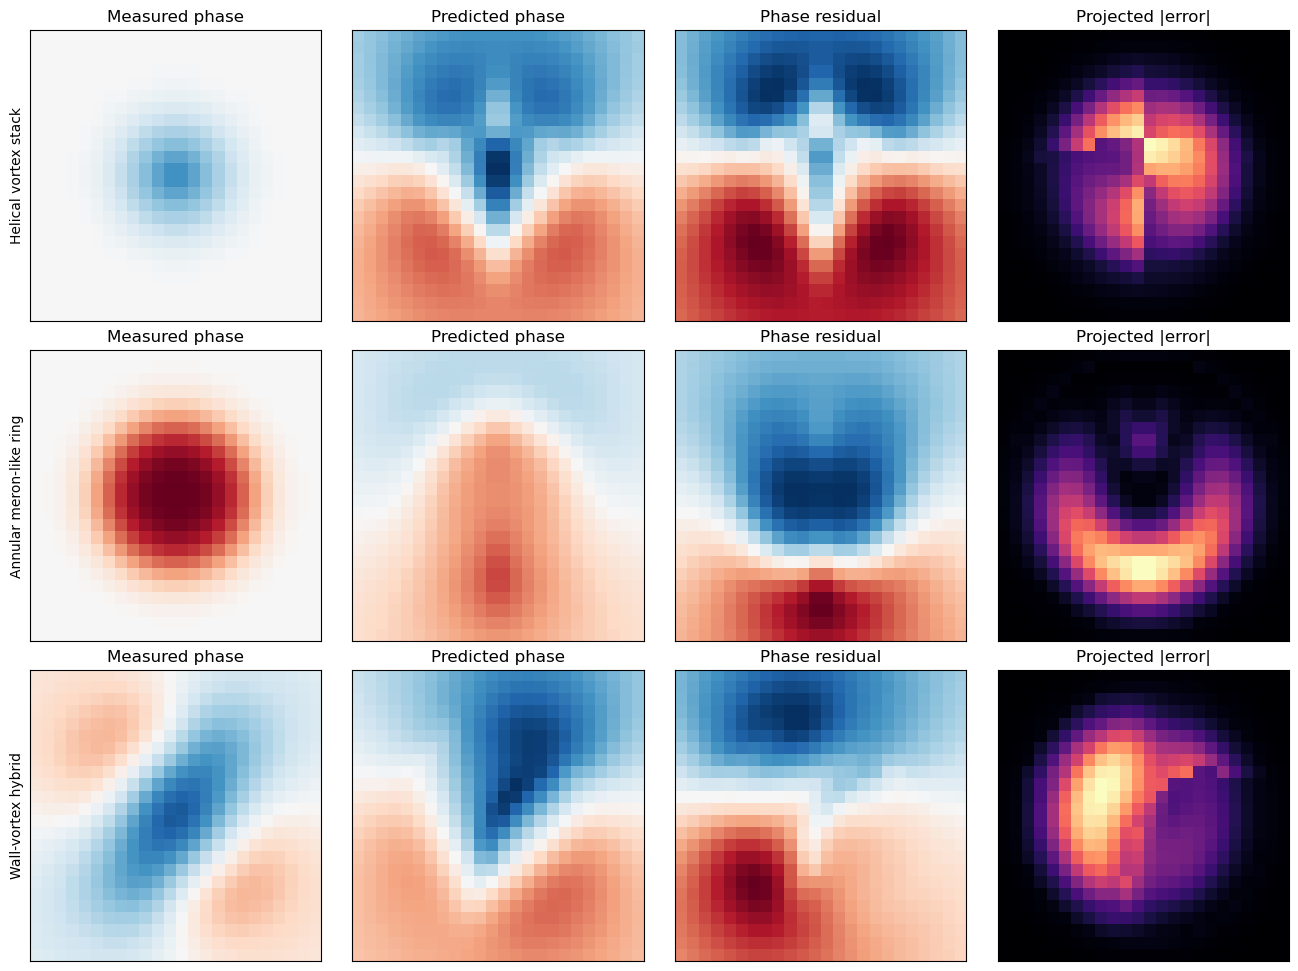

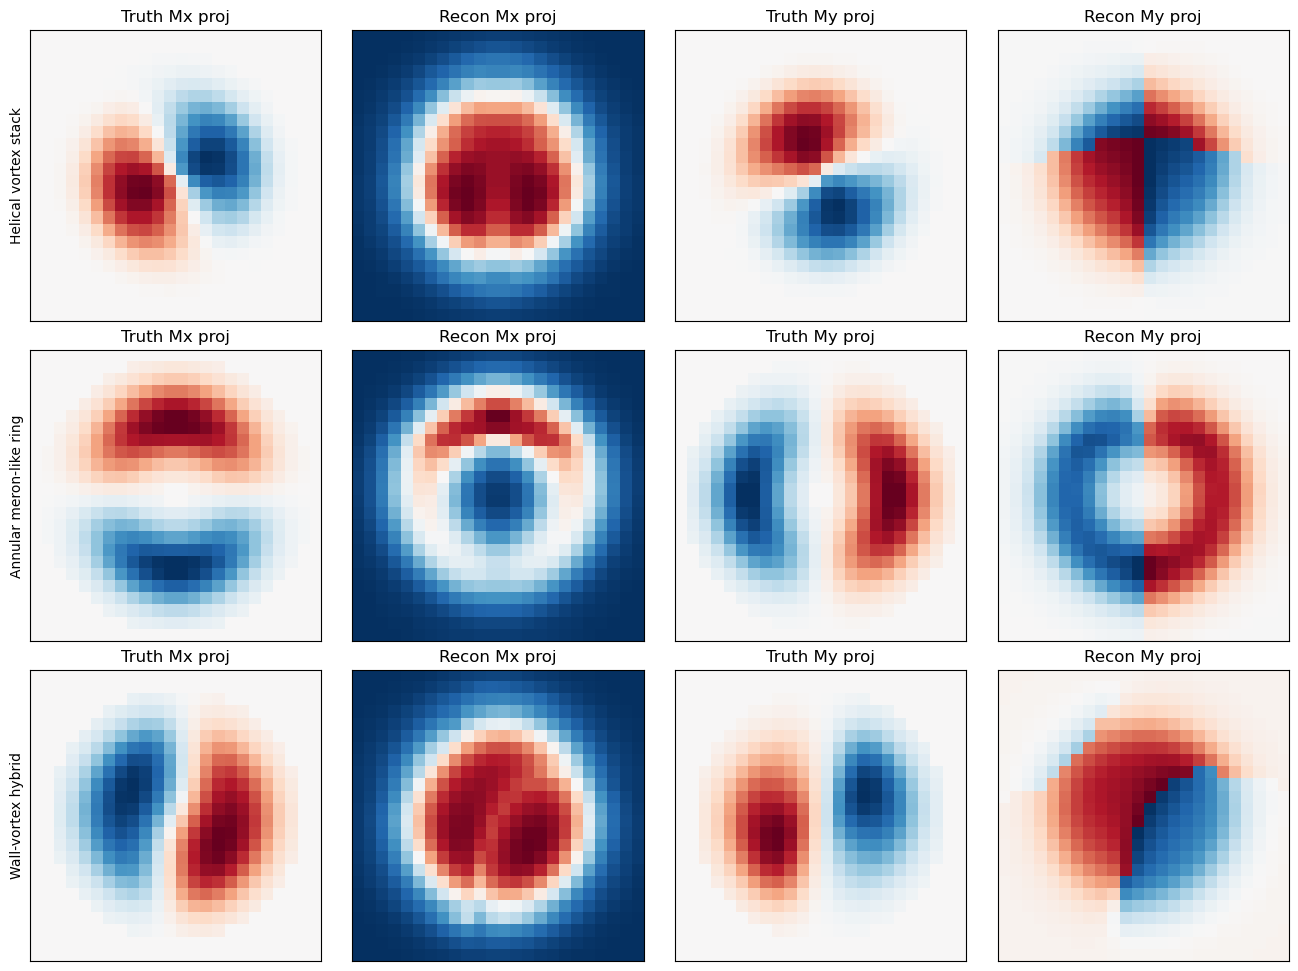

In [4]:
# Plot phase fits and projected magnetization comparisons for all cases
print(f"{'Case':<22} {'phase_rms':>12} {'proj_rel_err':>14} {'loss_final':>12}")
print('-' * 64)
for row in summary_rows:
    print(f"{row['case']:<22} {row['phase_rms']:>12.6f} {row['projected_rel_err']:>14.6f} {row['loss_final']:>12.6f}")

fig, axes = plt.subplots(len(stress_results), 4, figsize=(13, 3.2 * len(stress_results)), squeeze=False, constrained_layout=True)
for row_idx, case_name in enumerate(stress_results):
    case = stress_results[case_name]
    phi_true = case['phi_true']
    phi_pred = case['phi_pred']
    proj_true = case['proj_true']
    proj_recon = case['proj_recon']
    residual = phi_pred - phi_true
    vmax_phase = max(np.max(np.abs(phi_true)), np.max(np.abs(phi_pred)), 1e-12)
    vmax_proj = max(np.max(np.abs(proj_true)), np.max(np.abs(proj_recon)), 1e-12)
    axes[row_idx, 0].imshow(phi_true, cmap='RdBu_r', vmin=-vmax_phase, vmax=vmax_phase)
    axes[row_idx, 0].set_title('Measured phase')
    axes[row_idx, 1].imshow(phi_pred, cmap='RdBu_r', vmin=-vmax_phase, vmax=vmax_phase)
    axes[row_idx, 1].set_title('Predicted phase')
    axes[row_idx, 2].imshow(residual, cmap='RdBu_r')
    axes[row_idx, 2].set_title('Phase residual')
    axes[row_idx, 3].imshow(np.linalg.norm(proj_true - proj_recon, axis=-1), cmap='magma')
    axes[row_idx, 3].set_title('Projected |error|')
    axes[row_idx, 0].set_ylabel(case['title'])
    for col in range(4):
        axes[row_idx, col].set_xticks([])
        axes[row_idx, col].set_yticks([])
plt.show()

fig, axes = plt.subplots(len(stress_results), 4, figsize=(13, 3.2 * len(stress_results)), squeeze=False, constrained_layout=True)
for row_idx, case_name in enumerate(stress_results):
    case = stress_results[case_name]
    proj_true = case['proj_true']
    proj_recon = case['proj_recon']
    axes[row_idx, 0].imshow(proj_true[..., 0], cmap='RdBu_r')
    axes[row_idx, 0].set_title('Truth Mx proj')
    axes[row_idx, 1].imshow(proj_recon[..., 0], cmap='RdBu_r')
    axes[row_idx, 1].set_title('Recon Mx proj')
    axes[row_idx, 2].imshow(proj_true[..., 1], cmap='RdBu_r')
    axes[row_idx, 2].set_title('Truth My proj')
    axes[row_idx, 3].imshow(proj_recon[..., 1], cmap='RdBu_r')
    axes[row_idx, 3].set_title('Recon My proj')
    axes[row_idx, 0].set_ylabel(case['title'])
    for col in range(4):
        axes[row_idx, col].set_xticks([])
        axes[row_idx, col].set_yticks([])
plt.show()

In [3]:
# Every 4th z-slice for all magnetization components: truth vs reconstruction for each case
for case_name, case in stress_results.items():
    show_every_fourth_slices(case['title'], case['rho_true'], case['m_true'], case['m_recon'])

NameError: name 'stress_results' is not defined

2026-04-20 22:44:52 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 22:44:52 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 22:44:52 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 22:44:52 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-20 22:44:52 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-20 22:44:52 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-20 22:45:09 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 22:45:09 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 22:45:09 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 22:45:09 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: '

Case                     zero_phase   warm_phase    zero_proj    warm_proj
--------------------------------------------------------------------------
helical_vortex             0.631659     0.345371     1.980282     1.816351
annular_meron              1.058235     0.070640     0.896422     0.133664
wall_vortex_hybrid         0.759081     0.120042     1.315522     0.744244


2026-04-20 22:45:44 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 22:45:44 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 22:45:44 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 22:45:44 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-20 22:45:44 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-20 22:45:44 NeuralMag:INFO [DemagField]: Set up demag tensor


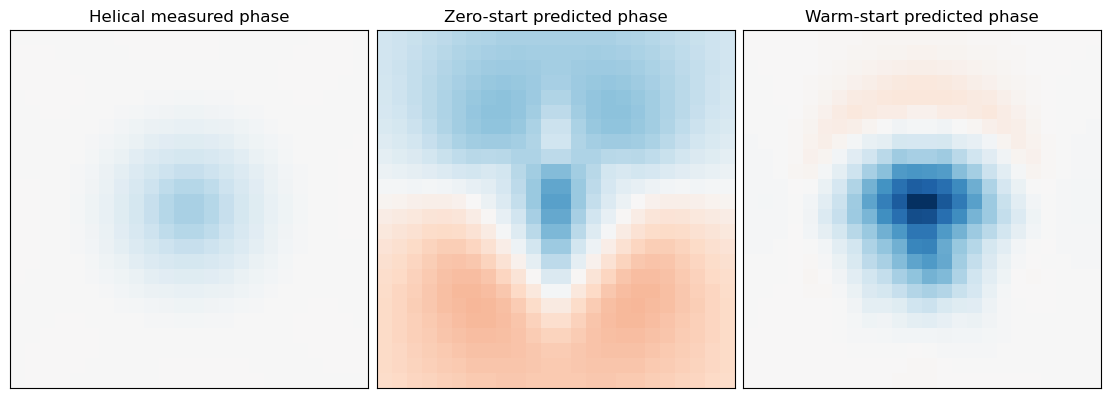

In [ ]:
# Next step: use the single-image 2D reconstruction as a projection-informed warm start
warm_summary_rows = []

for case_name, case in cases.items():
    rho_true = case['rho_true']
    phi_true = case['phi_true']
    support_2d = (np.max(rho_true, axis=0) > 0.25).astype(np.float32)
    inputs = add_units_to_inputs(phase=phi_true, pixel_size=float(PIXEL_SIZE.value), phase_unit='rad', pixel_size_unit='nm')
    lambdas = np.logspace(-5, -1, 8)
    lc = lcurve_sweep_vmap(phase=inputs['phase'], mask=support_2d, pixel_size=inputs['pixel_size'], lambdas=lambdas, solver='newton_cg')
    best_lam = lc.lambdas[lc.corner_index]
    result_2d = reconstruct_2d(phase=inputs['phase'], pixel_size=inputs['pixel_size'], mask=support_2d, lam=best_lam, solver='newton_cg')
    init_warm = extrude_projected_init(rho_true, np.asarray(result_2d.magnetization.value, dtype=np.float32))
    backend = make_neuralmag_backend(rho_true, float(PIXEL_SIZE.value))
    warm_result = invert_magnetization(
        phi_true,
        rho_true,
        backend,
        pixel_size=PIXEL_SIZE,
        lambda_phys=LAMBDA_PHYS,
        max_iter=MAX_ITER,
        lr=LEARNING_RATE,
        init=init_warm,
        axis='z',
        projection_threshold=0.0,
    )
    phi_pred_warm = np.asarray(warm_result.phi_pred)
    m_recon_warm = np.asarray(warm_result.m_recon)
    warm_summary_rows.append({
        'case': case_name,
        'zero_phase_rms': next(row['phase_rms'] for row in summary_rows if row['case'] == case_name),
        'warm_phase_rms': phase_rms(phi_pred_warm, phi_true),
        'zero_proj_rel_err': next(row['projected_rel_err'] for row in summary_rows if row['case'] == case_name),
        'warm_proj_rel_err': projected_rel_err(projected_from_volume(rho_true, m_recon_warm), projected_from_volume(rho_true, case['m_true']), support_2d),
        'warm_mean_mx': float(np.mean(m_recon_warm[..., 0][rho_true > 0.25])),
    })

print(f"{'Case':<22} {'zero_phase':>12} {'warm_phase':>12} {'zero_proj':>12} {'warm_proj':>12}")
print('-' * 74)
for row in warm_summary_rows:
    print(f"{row['case']:<22} {row['zero_phase_rms']:>12.6f} {row['warm_phase_rms']:>12.6f} {row['zero_proj_rel_err']:>12.6f} {row['warm_proj_rel_err']:>12.6f}")

helical_case = cases['helical_vortex']
helical_support = (np.max(helical_case['rho_true'], axis=0) > 0.25).astype(np.float32)
helical_inputs = add_units_to_inputs(phase=helical_case['phi_true'], pixel_size=float(PIXEL_SIZE.value), phase_unit='rad', pixel_size_unit='nm')
helical_lc = lcurve_sweep_vmap(phase=helical_inputs['phase'], mask=helical_support, pixel_size=helical_inputs['pixel_size'], lambdas=np.logspace(-5, -1, 8), solver='newton_cg')
helical_best_lam = helical_lc.lambdas[helical_lc.corner_index]
helical_2d = reconstruct_2d(phase=helical_inputs['phase'], pixel_size=helical_inputs['pixel_size'], mask=helical_support, lam=helical_best_lam, solver='newton_cg')
helical_init = extrude_projected_init(helical_case['rho_true'], np.asarray(helical_2d.magnetization.value, dtype=np.float32))
helical_backend = make_neuralmag_backend(helical_case['rho_true'], float(PIXEL_SIZE.value))
helical_warm = invert_magnetization(
    helical_case['phi_true'],
    helical_case['rho_true'],
    helical_backend,
    pixel_size=PIXEL_SIZE,
    lambda_phys=LAMBDA_PHYS,
    max_iter=MAX_ITER,
    lr=LEARNING_RATE,
    init=helical_init,
    axis='z',
    projection_threshold=0.0,
    )

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
vmax = max(np.max(np.abs(helical_case['phi_true'])), np.max(np.abs(np.asarray(helical_warm.phi_pred))), 1e-12)
axes[0].imshow(helical_case['phi_true'], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('Helical measured phase')
axes[1].imshow(np.asarray(stress_results['helical_vortex']['phi_pred']), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('Zero-start predicted phase')
axes[2].imshow(np.asarray(helical_warm.phi_pred), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title('Warm-start predicted phase')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [ ]:
# Three-view synthetic experiment: fit phases at -25°, 0°, and +25° jointly with L-BFGS
multiview_results = {}
multiview_summary_rows = []

for case_name, case in cases.items():
    rho_true = case['rho_true']
    m_true = case['m_true']
    view_data = synthesize_tilted_views(rho_true, m_true, angles_deg=MULTIVIEW_ANGLES_DEG, projection_threshold=0.0)
    phi_views = {angle: view_data[angle]['phi_true'] for angle in MULTIVIEW_ANGLES_DEG}
    support_2d = (np.max(rho_true, axis=0) > 0.25).astype(np.float32)
    inputs = add_units_to_inputs(
        phase=phi_views[0.0], pixel_size=float(PIXEL_SIZE.value), phase_unit='rad', pixel_size_unit='nm',
    )
    lambdas = np.logspace(-5, -1, 8)
    lc = lcurve_sweep_vmap(
        phase=inputs['phase'], mask=support_2d, pixel_size=inputs['pixel_size'], lambdas=lambdas, solver='newton_cg',
    )
    best_lam = lc.lambdas[lc.corner_index]
    result_2d = reconstruct_2d(
        phase=inputs['phase'], pixel_size=inputs['pixel_size'], mask=support_2d, lam=best_lam, solver='newton_cg',
    )
    init_multiview = extrude_projected_init(
        rho_true, np.asarray(result_2d.magnetization.value, dtype=np.float32),
    )
    backend = make_neuralmag_backend(rho_true, float(PIXEL_SIZE.value))
    mv_result = invert_magnetization_multiview(
        phi_views,
        rho_true,
        backend,
        pixel_size=PIXEL_SIZE,
        angles_deg=MULTIVIEW_ANGLES_DEG,
        lambda_phys=LAMBDA_PHYS,
        max_iter=MULTIVIEW_MAX_ITER,
        lr=MULTIVIEW_LEARNING_RATE,
        init=init_multiview,
        projection_threshold=0.0,
        optimizer=MULTIVIEW_OPTIMIZER,
        lbfgs_memory_size=MULTIVIEW_LBFGS_MEMORY_SIZE,
    )
    m_recon_mv = np.asarray(mv_result['m_recon'])
    proj_true = projected_from_volume(rho_true, m_true)
    proj_recon_mv = projected_from_volume(rho_true, m_recon_mv)
    phase_rms_by_view = {
        angle: phase_rms(mv_result['phi_pred_views'][idx], phi_views[angle])
        for idx, angle in enumerate(MULTIVIEW_ANGLES_DEG)
    }
    multiview_results[case_name] = {
        'title': case['title'],
        'rho_true': rho_true,
        'm_true': m_true,
        'm_recon': m_recon_mv,
        'proj_true': proj_true,
        'proj_recon': proj_recon_mv,
        'view_data': view_data,
        'phi_pred_views': np.asarray(mv_result['phi_pred_views']),
        'loss_history': np.asarray(mv_result['loss_history']),
        'phase_rms_by_view': phase_rms_by_view,
        'optimizer': mv_result['optimizer'],
    }
    multiview_summary_rows.append({
        'case': case_name,
        'zero_proj_rel_err': next(row['projected_rel_err'] for row in summary_rows if row['case'] == case_name),
        'warm_proj_rel_err': next(row['warm_proj_rel_err'] for row in warm_summary_rows if row['case'] == case_name),
        'multiview_proj_rel_err': projected_rel_err(proj_recon_mv, proj_true, support_2d),
        'multiview_phase_rms_mean': float(np.mean(list(phase_rms_by_view.values()))),
        'multiview_phase_rms_max': float(np.max(list(phase_rms_by_view.values()))),
    })

print(f"{'Case':<22} {'zero_proj':>12} {'warm_proj':>12} {'3view_proj':>12} {'3view_phase_mean':>18}")
print('-' * 84)
for row in multiview_summary_rows:
    print(
        f"{row['case']:<22} {row['zero_proj_rel_err']:>12.6f} {row['warm_proj_rel_err']:>12.6f} "
        f"{row['multiview_proj_rel_err']:>12.6f} {row['multiview_phase_rms_mean']:>18.6f}"
    )
print('Multiview optimizer:', MULTIVIEW_OPTIMIZER)

2026-04-20 23:10:01 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 23:10:01 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 23:10:01 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 23:10:01 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-20 23:10:01 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-20 23:10:01 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-20 23:10:58 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 23:10:58 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 23:10:58 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 23:10:58 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: '

Case                      zero_proj    warm_proj   3view_proj   3view_phase_mean
------------------------------------------------------------------------------------
helical_vortex             1.980282     1.816351     1.334309           0.002339
annular_meron              0.896422     0.133664     0.171249           0.001398
wall_vortex_hybrid         1.315522     0.744244     0.478672           0.001848
Multiview optimizer: lbfgs


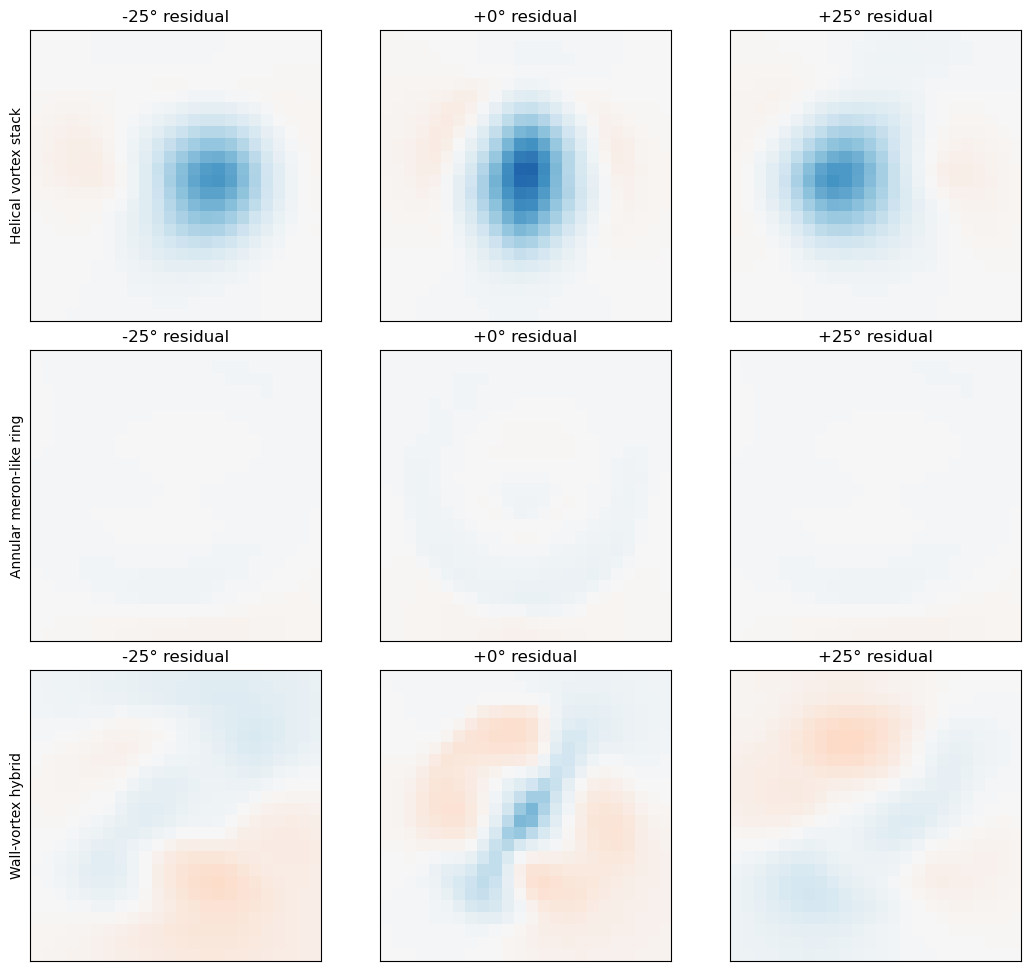

/tmp/ipykernel_756325/296800323.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


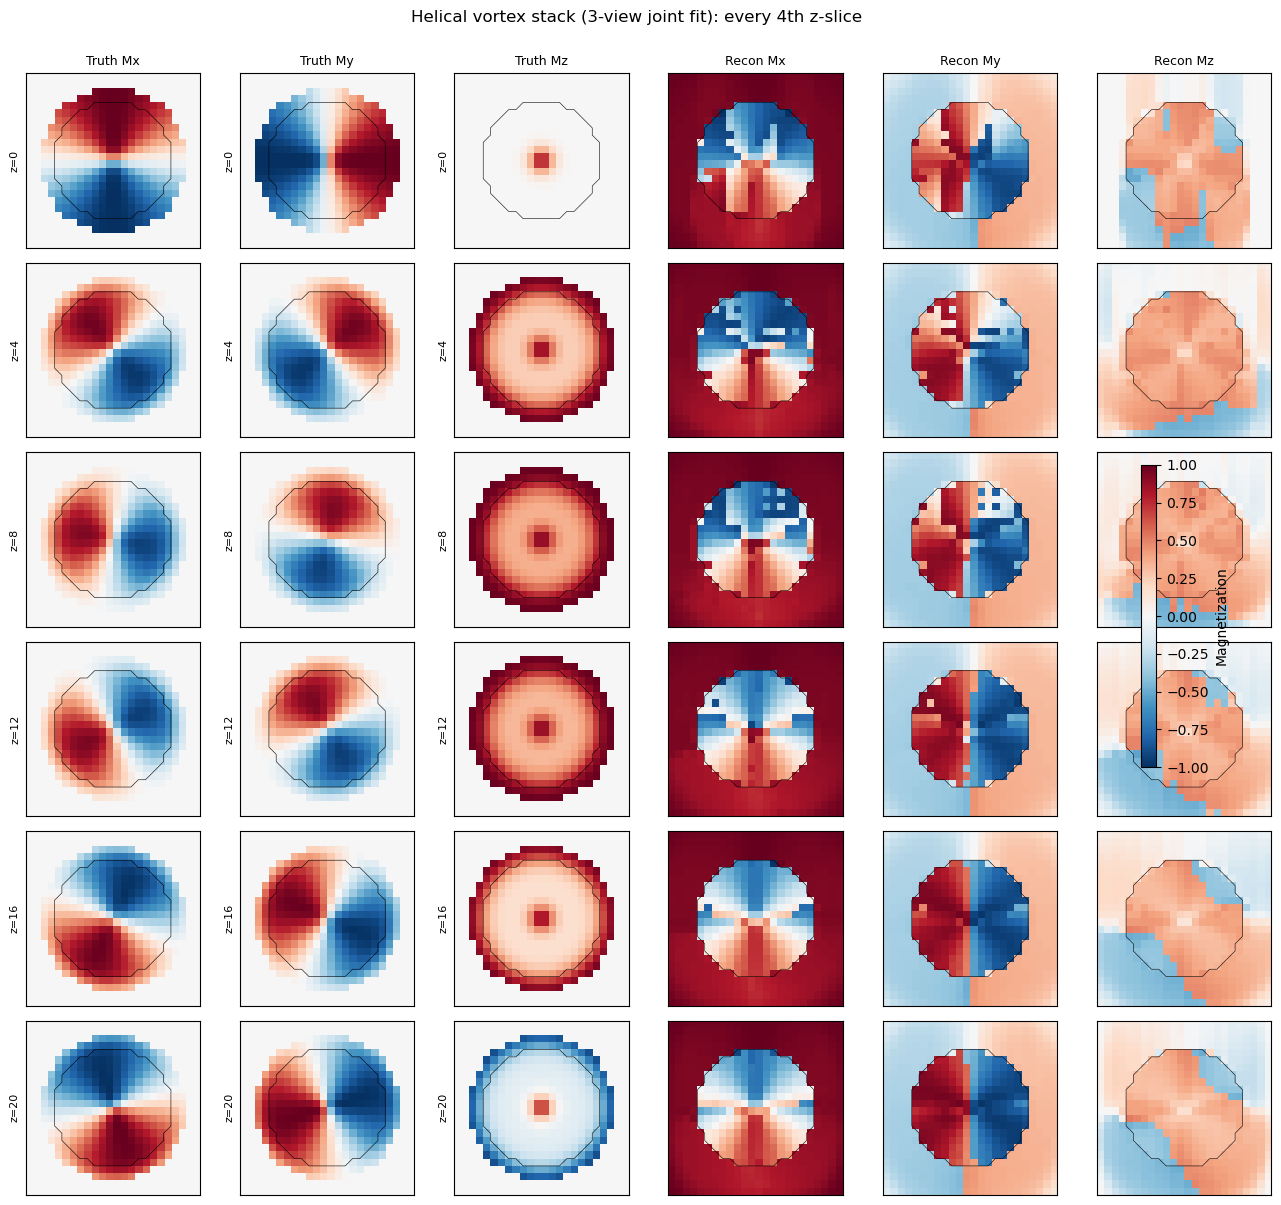

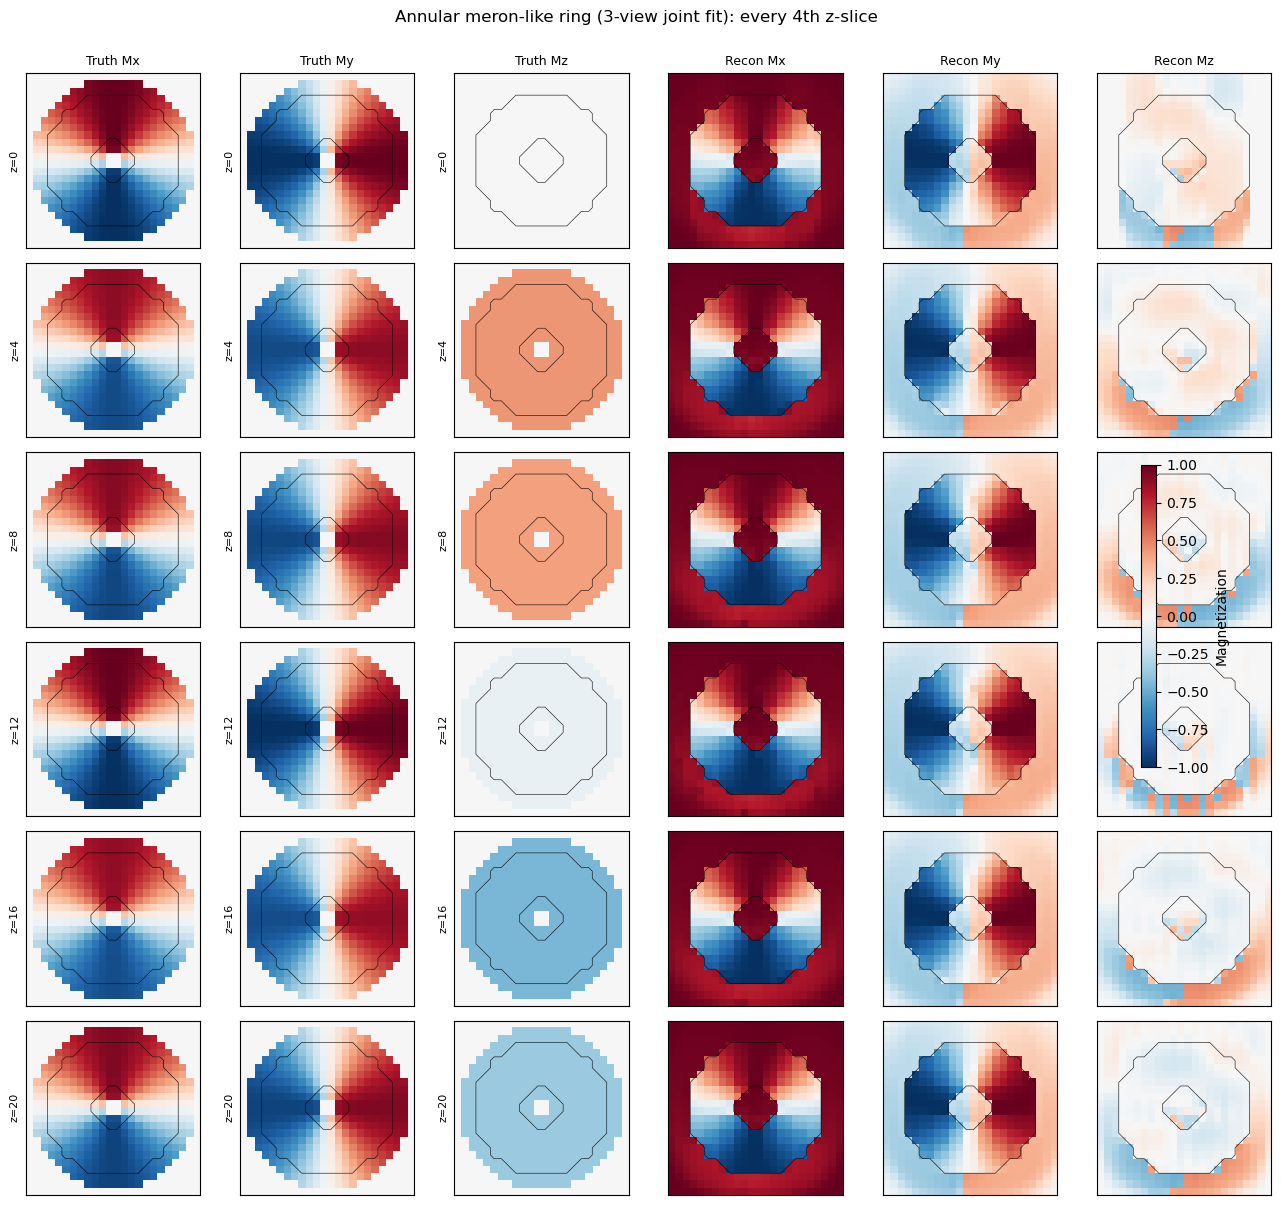

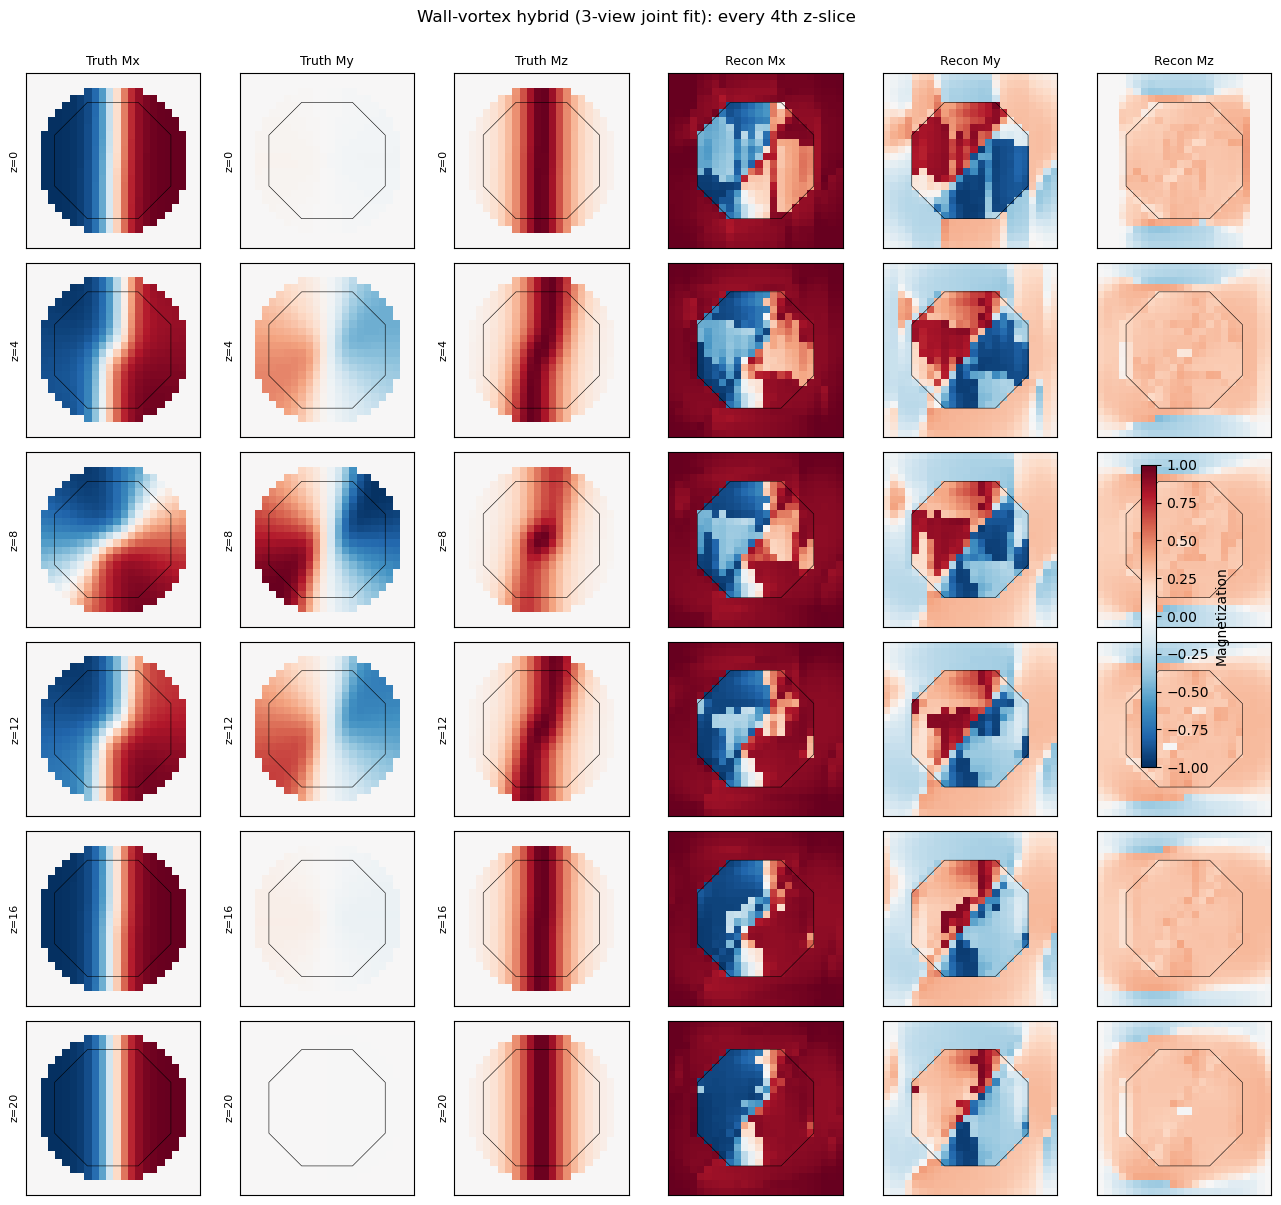

In [ ]:
# Compare the three-view predictions for each synthetic tilt and inspect 3D slices
fig, axes = plt.subplots(len(multiview_results), len(MULTIVIEW_ANGLES_DEG), figsize=(10.5, 3.2 * len(multiview_results)), squeeze=False, constrained_layout=True)
for row_idx, case_name in enumerate(multiview_results):
    case = multiview_results[case_name]
    vmax = max(
        np.max([np.max(np.abs(case['view_data'][angle]['phi_true'])) for angle in MULTIVIEW_ANGLES_DEG]),
        np.max(np.abs(case['phi_pred_views'])),
        1e-12,
    )
    for col_idx, angle in enumerate(MULTIVIEW_ANGLES_DEG):
        residual = case['phi_pred_views'][col_idx] - case['view_data'][angle]['phi_true']
        axes[row_idx, col_idx].imshow(residual, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[row_idx, col_idx].set_title(f'{angle:+.0f}° residual')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(case['title'])
        axes[row_idx, col_idx].set_xticks([])
        axes[row_idx, col_idx].set_yticks([])
plt.show()

for case_name, case in multiview_results.items():
    show_every_fourth_slices(f"{case['title']} (3-view joint fit)", case['rho_true'], case['m_true'], case['m_recon'])

In [ ]:
# Keep adding larger coplanar tilts until the joint-fit metrics stabilise
TILT_SWEEP_MAX_DEG = (25.0, 45.0, 65.0, 75.0, 85.0)
TILT_SWEEP_STAGE_ITER = 120
TILT_SWEEP_REL_TOL = 0.02
TILT_SWEEP_PATIENCE = 2

def cumulative_angles(max_angle_deg):
    positive = [angle for angle in COPLANAR_TILT_ANGLES_DEG if angle <= max_angle_deg]
    positive = sorted(set(float(angle) for angle in positive))
    return tuple(sorted([0.0] + positive + [-angle for angle in positive]))

tilt_sweep_results = {}
tilt_sweep_summary_rows = []

for case_name, case in cases.items():
    rho_true = case['rho_true']
    m_true = case['m_true']
    support_2d = (np.max(rho_true, axis=0) > 0.25).astype(np.float32)
    prev_init = np.asarray(multiview_results[case_name]['m_recon'], dtype=np.float32)
    prev_proj_err = None
    stable_steps = 0
    history = []
    final_entry = None

    for max_angle in TILT_SWEEP_MAX_DEG:
        angle_set = cumulative_angles(max_angle)
        view_data = synthesize_tilted_views(rho_true, m_true, angles_deg=angle_set, projection_threshold=0.0)
        phi_views = {angle: view_data[angle]['phi_true'] for angle in angle_set}
        backend = make_neuralmag_backend(rho_true, float(PIXEL_SIZE.value))
        mv_result = invert_magnetization_multiview(
            phi_views,
            rho_true,
            backend,
            pixel_size=PIXEL_SIZE,
            angles_deg=angle_set,
            lambda_phys=LAMBDA_PHYS,
            max_iter=TILT_SWEEP_STAGE_ITER,
            lr=MULTIVIEW_LEARNING_RATE,
            init=prev_init,
            projection_threshold=0.0,
            optimizer=MULTIVIEW_OPTIMIZER,
            lbfgs_memory_size=MULTIVIEW_LBFGS_MEMORY_SIZE,
        )
        m_recon = np.asarray(mv_result['m_recon'])
        proj_true = projected_from_volume(rho_true, m_true)
        proj_recon = projected_from_volume(rho_true, m_recon)
        proj_err = projected_rel_err(proj_recon, proj_true, support_2d)
        phase_rms_mean = float(np.mean([
            phase_rms(mv_result['phi_pred_views'][idx], phi_views[angle])
            for idx, angle in enumerate(angle_set)
        ]))
        rel_change = np.nan if prev_proj_err is None else abs(prev_proj_err - proj_err) / max(abs(prev_proj_err), 1e-12)
        if np.isfinite(rel_change) and rel_change < TILT_SWEEP_REL_TOL:
            stable_steps += 1
        else:
            stable_steps = 0
        entry = {
            'max_angle_deg': float(max_angle),
            'angles_deg': angle_set,
            'm_recon': m_recon,
            'proj_true': proj_true,
            'proj_recon': proj_recon,
            'view_data': view_data,
            'phi_pred_views': np.asarray(mv_result['phi_pred_views']),
            'loss_history': np.asarray(mv_result['loss_history']),
            'proj_rel_err': float(proj_err),
            'phase_rms_mean': phase_rms_mean,
            'rel_change': float(rel_change) if np.isfinite(rel_change) else np.nan,
            'converged_here': stable_steps >= TILT_SWEEP_PATIENCE,
            'optimizer': mv_result['optimizer'],
        }
        history.append(entry)
        final_entry = entry
        prev_init = m_recon
        prev_proj_err = proj_err
        if stable_steps >= TILT_SWEEP_PATIENCE:
            break

    tilt_sweep_results[case_name] = {
        'title': case['title'],
        'history': history,
        'final': final_entry,
    }
    tilt_sweep_summary_rows.append({
        'case': case_name,
        'warm_proj_rel_err': next(row['warm_proj_rel_err'] for row in warm_summary_rows if row['case'] == case_name),
        'three_view_proj_rel_err': next(row['multiview_proj_rel_err'] for row in multiview_summary_rows if row['case'] == case_name),
        'final_proj_rel_err': final_entry['proj_rel_err'],
        'final_phase_rms_mean': final_entry['phase_rms_mean'],
        'final_max_angle_deg': final_entry['max_angle_deg'],
        'num_views': len(final_entry['angles_deg']),
        'converged': final_entry['converged_here'],
    })

print(f"{'Case':<22} {'warm_proj':>12} {'3view_proj':>12} {'final_proj':>12} {'max_tilt':>10} {'views':>7} {'conv':>6}")
print('-' * 96)
for row in tilt_sweep_summary_rows:
    print(
        f"{row['case']:<22} {row['warm_proj_rel_err']:>12.6f} {row['three_view_proj_rel_err']:>12.6f} "
        f"{row['final_proj_rel_err']:>12.6f} {row['final_max_angle_deg']:>10.1f} {row['num_views']:>7d} {str(row['converged']):>6}"
    )
print('Tilt sweep optimizer:', MULTIVIEW_OPTIMIZER)

2026-04-20 23:29:49 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 23:29:49 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 23:29:49 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 23:29:49 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-20 23:29:49 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-20 23:29:49 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-20 23:30:50 NeuralMag:INFO [Mesh] 3D, 24 x 24 x 24 (size = 5e-09 x 5e-09 x 5e-09)
2026-04-20 23:30:50 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-20 23:30:50 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-20 23:30:50 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: '

Case                      warm_proj   3view_proj   final_proj   max_tilt   views   conv
------------------------------------------------------------------------------------------------
helical_vortex             1.816351     1.334309     1.256679       85.0      17   True
annular_meron              0.133664     0.171249     0.078380       85.0      17  False
wall_vortex_hybrid         0.744244     0.478672     0.258614       85.0      17  False
Tilt sweep optimizer: lbfgs


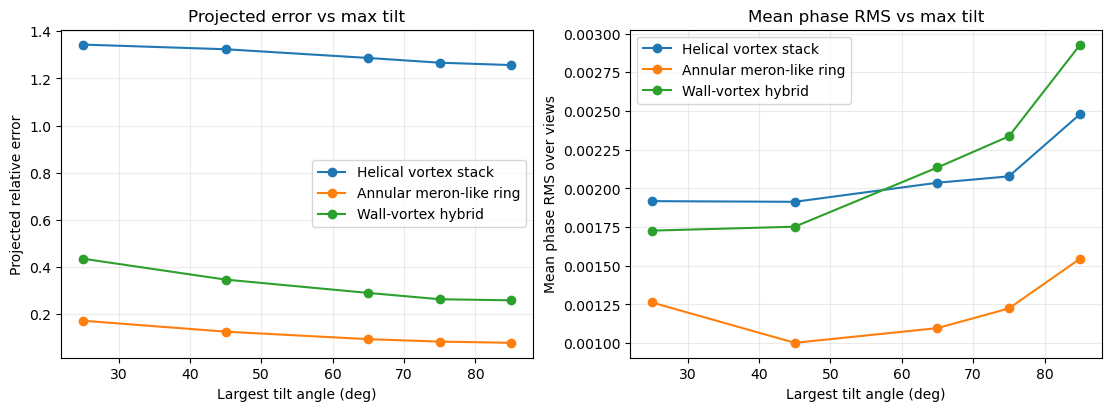

/tmp/ipykernel_756325/3954748021.py:269: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


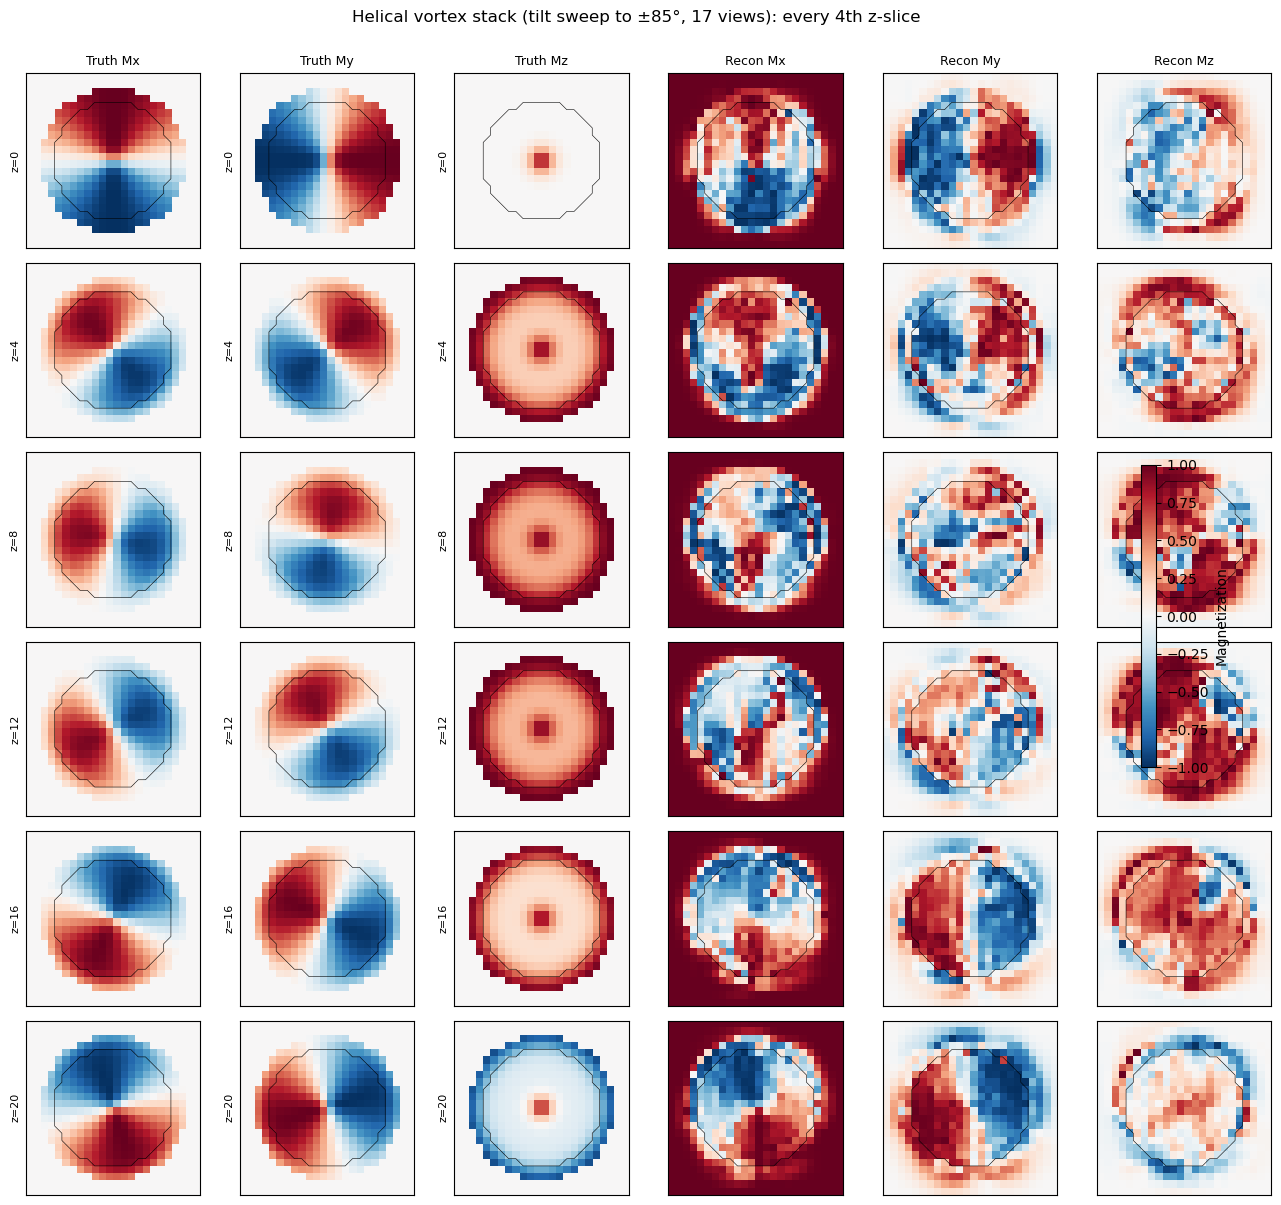

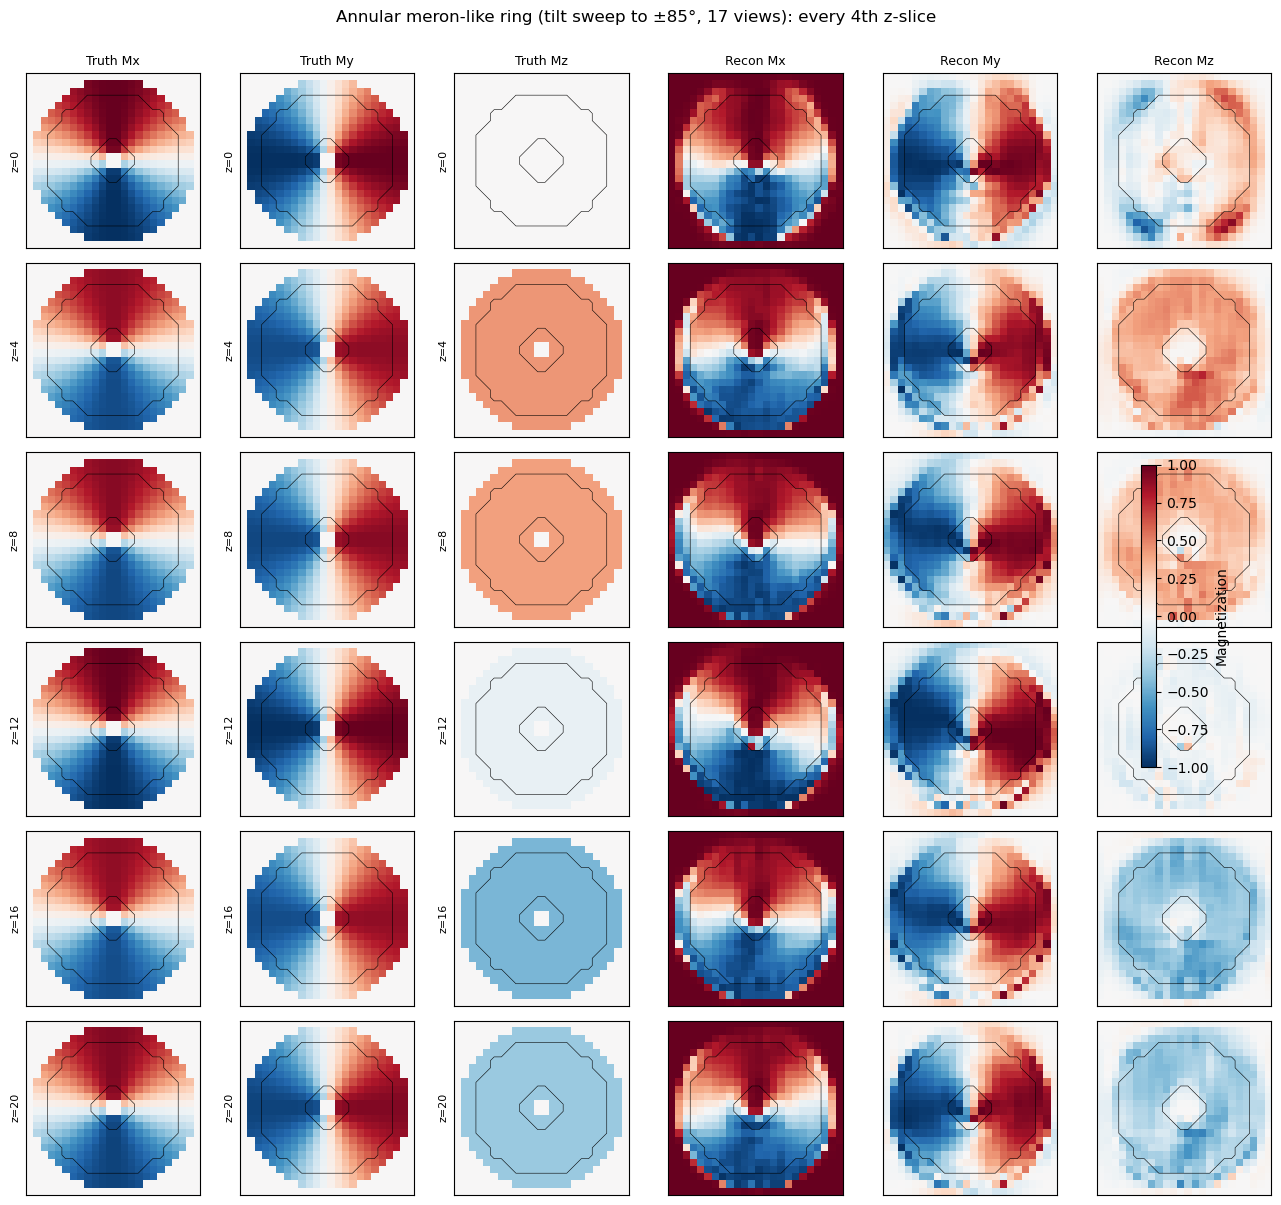

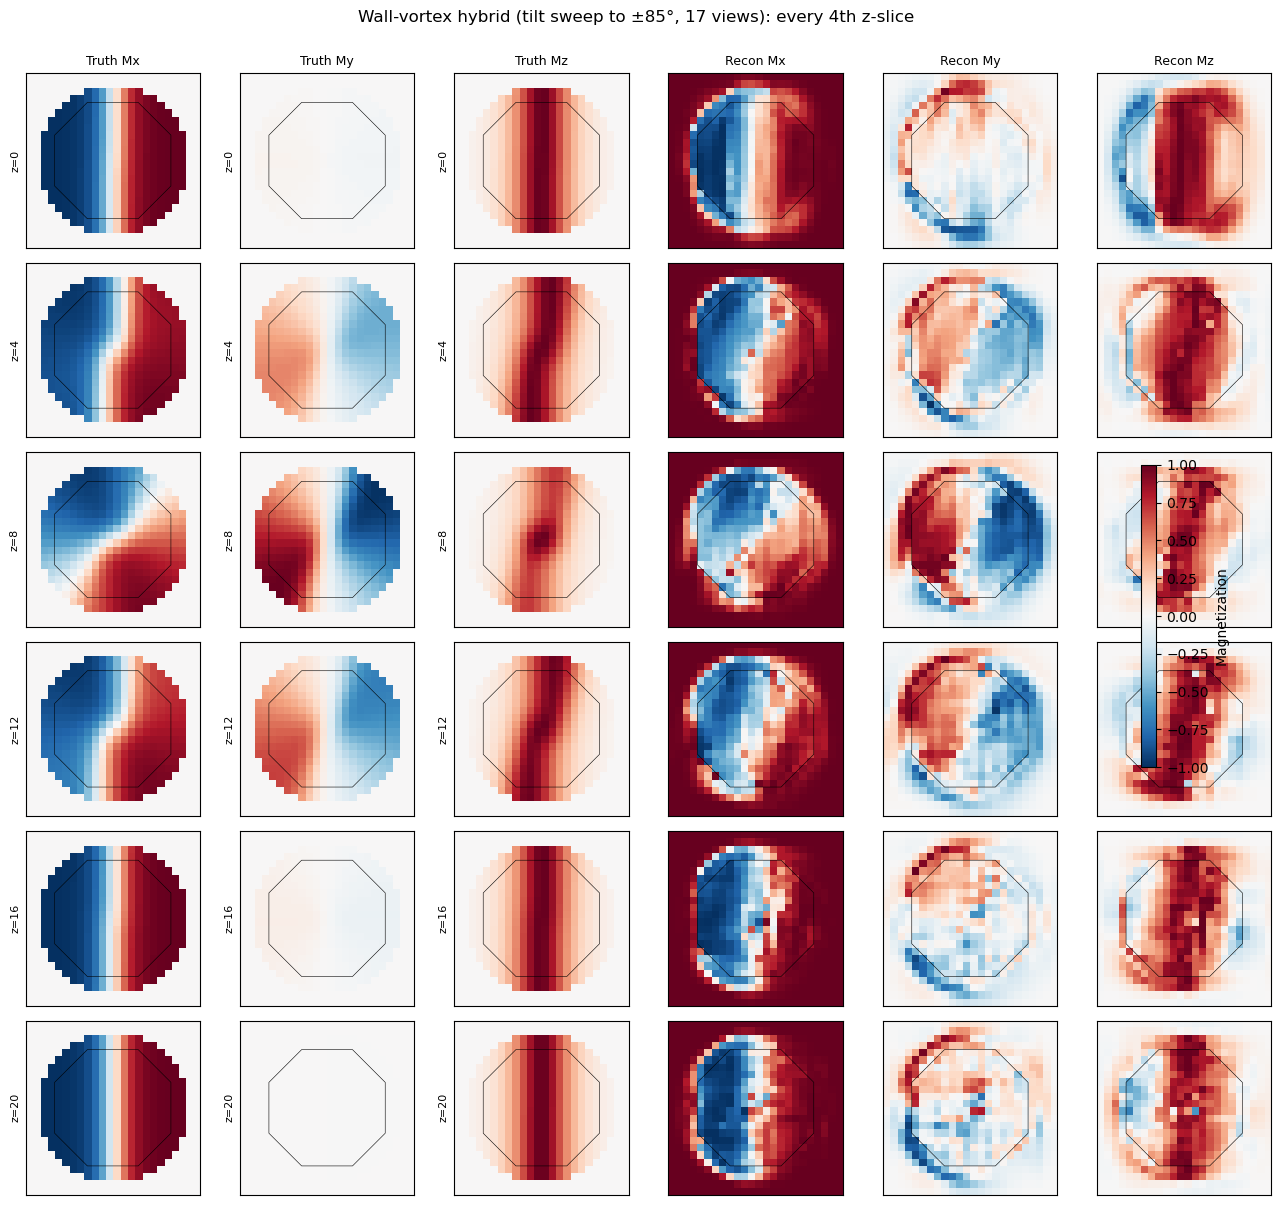

: 

In [ ]:
# Plot convergence with increasing tilt range and inspect the final converged reconstructions
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for case_name, result in tilt_sweep_results.items():
    history = result['history']
    max_tilts = [entry['max_angle_deg'] for entry in history]
    proj_errors = [entry['proj_rel_err'] for entry in history]
    phase_means = [entry['phase_rms_mean'] for entry in history]
    axes[0].plot(max_tilts, proj_errors, marker='o', label=result['title'])
    axes[1].plot(max_tilts, phase_means, marker='o', label=result['title'])
axes[0].set_title('Projected error vs max tilt')
axes[0].set_xlabel('Largest tilt angle (deg)')
axes[0].set_ylabel('Projected relative error')
axes[1].set_title('Mean phase RMS vs max tilt')
axes[1].set_xlabel('Largest tilt angle (deg)')
axes[1].set_ylabel('Mean phase RMS over views')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.show()

for case_name, result in tilt_sweep_results.items():
    final_entry = result['final']
    show_every_fourth_slices(
        f"{result['title']} (tilt sweep to ±{final_entry['max_angle_deg']:.0f}°, {len(final_entry['angles_deg'])} views)",
        cases[case_name]['rho_true'],
        cases[case_name]['m_true'],
        final_entry['m_recon'],
    )

## Summary

All reconstructions now produce **finite loss**: the NaN gradient bug in `project_unit_norm` is fixed, and the multi-view notebook experiments are numerically stable with both Adam and L-BFGS.

**Hard zero-start** (500 iter, `lambda_phys=1e-8`): every case still collapses to a demag-driven vortex-ring attractor.

| Case | warm `proj_rel_err` | `±25°` 3-view (L-BFGS) | coplanar sweep final | final max tilt | views | converged |
|---|---|---|---|---|---|---|
| Helical vortex | 1.82 | 1.33 | **1.26** | `±85°` | 17 | Yes |
| Annular meron | 0.13 | 0.17 | **0.078** | `±85°` | 17 | No |
| Wall-vortex hybrid | 0.74 | 0.48 | **0.259** | `±85°` | 17 | No |

Two points are now clear.

First, **L-BFGS is much better than the earlier Adam multi-view loop** for the helical vortex and wall-vortex hybrid. Even the fixed `±25°` three-view fit improves substantially once the optimiser is switched to L-BFGS.

Second, **adding more coplanar tilts beyond `±65°` continues to help**. The wall-vortex hybrid improves strongly, the annular meron becomes very accurate, and the helical vortex improves enough to meet the current plateau criterion by `±85°`, although its recovered slice topology is still visibly wrong in `Mz` and remains far from the true helical structure.

The practical conclusion is that **more coplanar views plus a stronger optimiser do recover more of the missing 3D information**, but not uniformly. For the annular and wall-vortex cases, the expanded tilt series is already quite informative. For the helical vortex, the phase fits and projected error improve, but the recovered `Mz` and slice morphology still show that a single coplanar tilt axis is not fully resolving the true 3D state. That case likely still needs a non-coplanar tilt axis, stronger state-specific priors, or a lower-dimensional parameterisation of the helical structure.